# Tarea 6.
# Clase de Introduction to Machine Learning
#### alumno Carlos Alfonzo
## Implementación de Árbol de Decisión Clásico

Este cuaderno jupyter contiene la implementación de un árbol de decisión binario utilizando **Entropía** como métrica de impureza. 

### Requerimientos:
- (a) Uso de Entropía Clásica (Classic Entropy Impurity)
- (b) Árbol binario clásico en Python (sin JAX).
- (c) Dataset 2D con 5 distribuciones Gaussianas por clase (3 clases).
- (d) División en Entrenamiento, Validación y Prueba.
- (e) Validación cruzada (K-fold) y métricas (Exactitud, Precisión, Sensibilidad, F1).

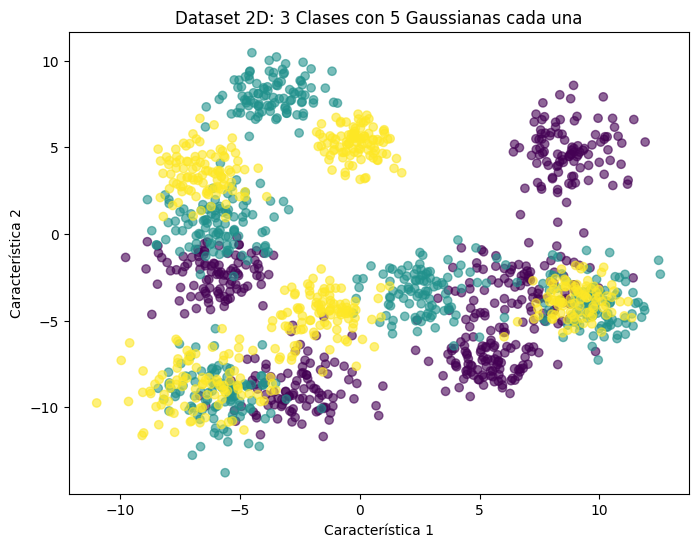

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# función para generar los datos sintéticos con 5 Gaussianas por cada una de las 3 clases
def generar_dataset():
    X = [] # Lista para almacenar las características 2D
    y = [] # Lista para almacenar las etiquetas de clase, esta es la variable objetivo y
    for clase_id in range(3): # Iteramos por cada una de las 3 clases: 0, 1 y 2
        for _ in range(5): # Cada clase tiene 5 grupos (Gaussianas) diferentes, no necesitamos el definir el contador por eso ponemos _
            centro = np.random.uniform(-10, 10, size=2) # Definimos un centro aleatorio para el grupo usando la función random.uniform de np-
            covarianza = np.eye(2) * np.random.uniform(0.5, 2.5) # la covarianza se utiliza para controlar la dispersión de los puntos alrededor del centro, aquí usamos una matriz identidad escalada por un factor aleatorio para variar la dispersión entre los grupos
            puntos = np.random.multivariate_normal(centro, covarianza, 100) # Generamos 100 puntos aleatorios con la funcion multivariada/gaussiana con un centro y matriz de covarianza definida arriba, con esto simulamos un grupo de datos que pertenece a una misma clase y que están agrupados alrededor de un punto central y que tenga cierta dispersion, asi generamos un dataset sintetico para probarl
            X.append(puntos) # Agregamos los puntos al conjunto total
            y.append(np.full(100, clase_id)) # Asignamos la etiqueta de clase correspondiente, np.full se utiliza para  crear un arreglo de tamaño 100 lleno con el valor de clase_id, esto para etiquetar cada punto generado con la clase a la que pertenece, asi cada grupo de puntos tendrá la misma etiqueta y podremos usar esto para entrenar nuestro modelo de clasificación posteriormente
    return np.vstack(X), np.concatenate(y) # entregamos los datos combinados, con vstack unimos todas las matrices de puntos en una sola matriz 2D y con concatenate unimos todas las etiquetas en un solo vector, asi tenemos un dataset completo con características y etiquetas listo para ser utilizado en el entrenamiento del modelo de árbol de decisión

X, y = generar_dataset() # Ahora si llamamos a la función para crear el dataset y la asignamos anuestras variables X de las caracteristicas y y para el objetivo (clase)

# Visualización del dataset generado con matplotlib
plt.figure(figsize=(8, 6)) # Definimos el tamaño de la figura de tamaño 8x6 pulgadas
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.6) # graficamos los puntos con colores por clase usando como paleta viridis y un poco de transparencia
plt.title("Dataset 2D: 3 Clases con 5 Gaussianas cada una") # Título del gráfico
plt.xlabel("Característica 1") # Etiqueta eje X
plt.ylabel("Característica 2") # Etiqueta eje Y
plt.show() # Mostramos el gráfico

con esto podemos visualizar cómo se distribuyen los puntos de cada clase en el espacio 2D y verificar que efectivamente tenemos 3 grupos de puntos con diferentes colores que representan las 3 clases, cada grupo tiene una forma más o menos circular debido a la generación con Gaussianas, esto nos permitirá probar nuestro modelo de árbol de decisión para ver cómo clasifica estos puntos basándose en sus características.

## Lógica del Árbol de Decisión
Acá implementamos la estructura del árbol de decisión desde cero, utilizando la entropía como criterio para seleccionar las mejores divisiones en cada nodo.

In [10]:
#Función para calcular la entropía de un conjunto de datos
def calcular_entropia(etiquetas):
    _, conteos = np.unique(etiquetas, return_counts=True) # primero ontamos cuántas muestras hay de cada clase, como usamos np.unique, la primera variable la descartamos porque  no nos interesa el valor de las clases únicas, solo nos interesa el conteo de cada clase para calcular la probabilidad
    probabilidades = conteos / len(etiquetas) # Calculamos la probabilidad de cada clase al dividir su respectivo   conteo por el total de muestras, esto nos da la proporción de cada clase en el conjunto de datos, lo cual es necesario para calcular la entropía, ya que esta se basa en la distribución de las clases dentro del conjunto
    # Aplicamos la fórmula: -sum(p * log2(p)) que es    la definición de entropía, donde p es la probabilidad de cada clase, sumamos el producto de la probabilidad por su logaritmo en base 2 para cada clase y luego negamos el resultado para obtener la entropía total del conjunto de datos, esto nos da una medida de la impureza o desorden del conjunto, siendo 0 cuando todas las muestras pertenecen a una sola clase y aumentando a medida que las clases se mezclan más
    return -np.sum(probabilidades * np.log2(probabilidades + 1e-9)) # Sumamos y negamos el resultado

# creamos una clase Nodo para representar un Nodo dentro del árbol binario
class Nodo:
    def __init__(self, feature=None, umbral=None, izq=None, der=None, *, valor=None): #las variables que se inicializan cuando instanciamos un objeto
        self.feature = feature # Índice de la característica (0 o 1 en este caso), esto es, la columna del dataset que se va a usar para dividir los datos en este nodo, como nuestro dataset tiene solo 2 características, el valor de feature será 0 para la primera característica y 1 para la segunda característica, esto nos permite decidir cómo dividir los datos en función de sus valores
        self.umbral = umbral # Valor para dividir los datos en este nodo, esto es el valor específico de la característica seleccionada que se usará como punto de corte para dividir los datos en dos grupos, por ejemplo, si feature es 0 y umbral es 5, entonces los datos con la primera característica menor o igual a 5 irán al sub-árbol izquierdo y los demás al sub-árbol derecho
        self.izq = izq # Referencia al subarbol izquierdo
        self.der = der # Referencia al subarbol derecho
        self.valor = valor # Clase predicha (solo si el nodo es una hoja)

    def es_hoja(self):
        return self.valor is not None # Es hoja si tiene un valor de clase asignado, esto es decir, si el nodo no tiene hijos (izq y der son None) y tiene un valor de clase definido, entonces es un nodo hoja, lo que significa que representa una decisión final en el árbol donde se asigna una clase específica a los datos que llegan a ese punto del árbol

para la clase Nodo, las variables se inicializan con valores por defecto de None, lo que significa que cuando se crea un nodo, no necesariamente tiene que tener una característica, umbral o hijos definidos, esto es útil porque en el caso de los nodos hoja, solo se asignará un valor de clase a la variable valor y las demás variables quedarán como None, mientras que en los nodos internos, se asignarán valores a feature y umbral para definir cómo dividir los datos, y se crearán referencias a los sub-árboles izquierdo y derecho, pero el valor de clase permanecerá como None ya que estos nodos no representan una clase específica sino una decisión basada en las características.

In [11]:
#Clase del Árbol de Decisión con Entropía
class ArbolDecision:
    def __init__(self, prof_max=10, min_muestras=2): # usaremos dos parámetros para controlar el crecimiento del árbol, prof_max para limitar la profundidad máxima del árbol y min_muestras para establecer el número mínimo de muestras que debe tener un nodo para que pueda ser dividido, esto es importante para evitar que el árbol crezca demasiado y se sobreajuste a los datos de entrenamiento, ya que si un nodo tiene muy pocas muestras, dividirlo no aportará información útil y solo aumentará la complejidad del modelo sin mejorar su capacidad de generalización, overfit.
        self.prof_max = prof_max # Máxima profundidad permitida
        self.min_muestras = min_muestras # Mínimo de muestras para dividir un nodo
        self.raiz = None # Nodo raíz inicial

    def ajustar(self, X, y):
        self.raiz = self._construir_arbol(X, y) # Iniciamos la construcción desde la raíz

    def _construir_arbol(self, X, y, prof_actual=0): # usamos _ para indicar que es un método interno de la clase, este método se llama recursivamente para construir el árbol, recibe los datos X e y correspondientes al nodo actual, así como la profundidad actual del nodo en el árbol (prof_actual), esto nos permite controlar cuándo detener la recursión basándonos en la profundidad máxima permitida o en otras condiciones de parada, como la pureza del nodo o el número mínimo de muestras
        muestras, features = X.shape # Obtenemos filas y columnas de los datos usando el shape de X
        clases_unicas = len(np.unique(y)) # Revisamos cuántas clases quedan

        # verificamos condiciones para detener el crecimiento, si la prof actual es mayor o igual a la profundidad máxima permitida, o si solo queda una clase en el nodo (lo que significa que el nodo es puro), o si el número de muestras es menor que el mínimo requerido para dividir, entonces no se debe seguir dividiendo el nodo, ya que no aportará información adicional y podría llevar a un sobreajuste, por lo tanto, en cualquiera de estas condiciones, se crea un nodo hoja con la clase más común entre las muestras actuales,
        if (prof_actual >= self.prof_max or clases_unicas == 1 or muestras < self.min_muestras):
            frecuencias = np.bincount(y) # Contamos votos de cada clase, utilizando np.bincount para contar cuántas muestras hay de cada clase
            return Nodo(valor=np.argmax(frecuencias)) # Creamos nodo hoja con la clase más común,con np.argmax para obtener la clase con la mayor cantidad de muestras, esto asigna a ese nodo hoja la clase que representa la mayoría de las muestras que llegan a ese punto del árbol

        # Buscamos la mejor división basada en ganancia de información
        mejor_f, mejor_u = self._mejor_criterio(X, y, features) # Buscamos mejor característica y umbral usando _mejor_criterio, abajo explicado, mejor_f   será el índice de la característica que proporciona la mejor división y mejor_u será el valor del umbral para esa característica que maximiza la ganancia de información, esto es, la reducción en la entropía al dividir los datos según esa característica y umbral específicos

        if mejor_f is None: # Si no hay mejora posible
            return Nodo(valor=np.argmax(np.bincount(y))) # regresamos la hoja con clase que aparece mas

        # Dividimos recursivamente los datos en dos subarboles
        izq_idx = np.where(X[:, mejor_f] <= mejor_u)[0] # Índices para el lado izquierdo, usamos np.where para obtener los índices de las muestras que cumplen la condición de estar <= al umbral en la característica seleccionada, esto nos permite separar los datos en dos grupos: los que van al sub-árbol izquierdo y los que van al sub-árbol derecho
        der_idx = np.where(X[:, mejor_f] > mejor_u)[0] # Para el derecho se seleccionan los que superen al umbral, el complemento del izq.
        izq_nodo = self._construir_arbol(X[izq_idx, :], y[izq_idx], prof_actual + 1) # construimos hijo izquierdo, usamos : para seleccionar todas las características de las muestras que cumplen la condición para el sub-árbol izquierdo, y aumentamos la profundidad actual en 1 para la llamada recursiva, esto nos permite seguir construyendo el árbol hacia abajo hasta que se cumpla alguna de las condiciones de parada
        der_nodo = self._construir_arbol(X[der_idx, :], y[der_idx], prof_actual + 1) # construimos hijo derecho

        return Nodo(mejor_f, mejor_u, izq_nodo, der_nodo) # regresamos el nodo con sus hijos

    def _mejor_criterio(self, X, y, n_features): #otra función  interna para encontrar la mejor característica y umbral para dividir los datos en el nodo actual, esta función iterará sobre todas las características y posibles umbrales para calcular la ganancia de información que se obtendría al dividir los datos según cada combinación de característica y umbral, y seleccionará la combinación que maximice esa ganancia, esto es fundamental para construir un árbol de decisión efectivo, ya que elegir la mejor división en cada nodo es lo que permite al árbol aprender a clasificar los datos de manera eficiente
        mejor_ganancia = -1 # Inicializamos la ganancia más alta encontrada en -1, esto es un valor inicial que se actualizará a medida que se encuentren divisiones mejores, cualquier ganancia calculada que sea mayor que -1 se considerará como una mejora válida, lo que nos permite encontrar la mejor división incluso si la ganancia es muy pequeña
        f_idx, u_val = None, None # Variables para almacenar la mejor característica y umbral encontrados, inicializadas en 0.

        for f in range(n_features): # Iteramos por cada característica
            umbrales = np.unique(X[:, f]) # Obtenemos valores únicos para probar divisiones
            for u in umbrales:
                ganancia = self._calcular_ganancia(y, X[:, f], u) # Calculamos mejora en entropía con la funcion interna definida abajo
                if ganancia > mejor_ganancia: # Si la ganancia encontrada es mejor que la anterior
                    mejor_ganancia = ganancia # Actualizamos ganancia
                    f_idx = f # Guardamos el índice de la característica
                    u_val = u # y el valor del umbral
        return f_idx, u_val

    def _calcular_ganancia(self, y, columna, umbral): # acá calculamos la ganancia de información que se obtendría al dividir los datos según una característica específica (columna) y un umbral dado, esta función es crucial para evaluar la calidad de una posible división en el árbol de decisión, ya que la ganancia de información mide cuánto se reduce la entropía (o impureza) del conjunto de datos al realizar esa división, lo que nos ayuda a seleccionar la mejor característica y umbral para dividir los datos en cada nodo del árbol
        ent_padre = calcular_entropia(y) # Entropía antes de dividir,   para calcular la medida de impureza del nodo actual antes de realizar cualquier división
        izq_i = np.where(columna <= umbral)[0] # Índices menores o iguales
        der_i = np.where(columna > umbral)[0] # Índices mayores

        if len(izq_i) == 0 or len(der_i) == 0:
            return 0 # No hay ganancia si un lado queda vacío, esto es   una condición de seguridad para evitar divisiones que no aporten información útil

        # calculamos la entropía ponderada de los hijos
        n = len(y) # Total de muestras
        n_izq, n_der = len(izq_i), len(der_i) # Muestras en cada lado
        ent_hijos = (n_izq/n)*calcular_entropia(y[izq_i]) + (n_der/n)*calcular_entropia(y[der_i])#acá   calculamos la entropía ponderada de los hijos, multiplicando la entropía de cada hijo por la proporción de muestras que tiene respecto al total, esto nos da una medida de la impureza promedio después de la división, lo que nos permite comparar con la entropía del nodo padre para determinar cuánto se ha mejorado/reducido la impureza al realizar esa división específica
        return ent_padre - ent_hijos # regresamos la diferencia, que es la ganancia

    def predecir(self, X):
        return np.array([self._navegar(x, self.raiz) for x in X]) # Aplicamos  la función interna de navegación para cada punto

    def _navegar(self, x, nodo): #  esta función se encarga de recorrer el árbol de decisión para hacer una predicción para un punto de datos específico (x), comenzando desde la raíz del árbol y siguiendo las ramas según los valores de las características del punto hasta llegar a un nodo hoja, donde se devuelve la clase predicha, esta función es esencial para utilizar el árbol de decisión una vez que ha sido construido, ya que permite clasificar nuevos puntos de datos basándose en las decisiones aprendidas durante el entrenamiento
        if nodo.es_hoja(): return nodo.valor # Si es hoja, retornamos la clase
        # Seguimos el camino según el valor de la característica contra el umbral
        if x[nodo.feature] <= nodo.umbral: # si el valor de la característica del punto x en el índice especificado por nodo.feature es menor o igual al umbral definido en ese nodo, entonces seguimos la rama izquierda del árbol
            return self._navegar(x, nodo.izq) # Vamos a la izquierda
        return self._navegar(x, nodo.der) #  de lo contrario a la derecha

## Métricas y Validación para evaluar el modelo

In [12]:
# función para calcular métricas para un set de clasificación
def evaluar_modelo(y_verdadero, y_predicho):
    clases = np.unique(y_verdadero) # Obtenemos las etiquetas únicas
    exactitud = np.sum(y_verdadero == y_predicho) / len(y_verdadero) # Porcentaje total de aciertos, que equivale a la proporción de predicciones correctas sobre el total de muestras
    
    p_lista, s_lista, f1_lista = [], [], [] # Listas para promedios macro,esto es,  vamos a calcular la precisión, sensibilidad y F1-Score para cada clase por separado y luego promediar esos valores para obtener una métrica general que no esté sesgada por el desequilibrio de clases, esto es util en casos donde las clases no están balanceadas, ya que el promedio macro trata a cada clase por igual sin importar su frecuencia en el dataset
    for c in clases: # Calculamos métricas por cada clase
        tp = np.sum((y_verdadero == c) & (y_predicho == c)) # Verdaderos Positivos
        fp = np.sum((y_verdadero != c) & (y_predicho == c)) # Falsos Positivos
        fn = np.sum((y_verdadero == c) & (y_predicho != c)) # Falsos Negativos
        
        p = tp / (tp + fp) if (tp + fp) > 0 else 0 # cálculo de Precisión
        s = tp / (tp + fn) if (tp + fn) > 0 else 0 # Cálculo de Sensibilidad o Recall
        f1 = 2 * (p * s) / (p + s) if (p + s) > 0 else 0 # Cálculo de F1-Score, que es  la media armónica entre precisión y recall, proporcionando una medida equilibrada que considera tanto los falsos positivos como los falsos negativos, esto es  útil cuando se busca un balance entre precisión y recall, ya que el F1-Score penaliza más los casos donde uno de los dos es muy bajo, lo que ayuda a evitar modelos que tengan una alta precisión pero baja sensibilidad o al reves
        
        p_lista.append(p); s_lista.append(s); f1_lista.append(f1) # Guardamos resultados en las listas creadas arriba
    
    return exactitud, np.mean(p_lista), np.mean(s_lista), np.mean(f1_lista) # regresamos promedios ahora sí

# Implementación de Validación Cruzada (K-Fold)
def realizar_kfold(X, y, k=5): # con esta función realizamos validación cruzada utilizando K-Fold, esta técnica consiste en dividir el conjunto de datos en K partes iguales y entrenamos el modelo K veces, cada vez utilizando un pliegue diferente como conjunto de validación y los restantes K-1 pliegues como conjunto de entrenamiento, esto nos permite evaluar el rendimiento del modelo de manera más robusta y obtener una estimación más confiable de su capacidad de generalización, ya que se prueba en diferentes subconjuntos de los datos
    indices = np.arange(len(y)) # Creamos un arreglo de índices para los datos, para manipular los índices de las muestras al realizar las divisiones en los pliegues
    np.random.shuffle(indices) # Mezclamos los índices aleatoriamente
    pliegues = np.array_split(indices, k) # Dividimos los índices en K partes iguales
    resultados = [] # Lista para guardar métricas de cada iteración
    for i in range(k): # Iteramos por cada pliegue
        v_idx = pliegues[i] # Índices para validación en esta vuelta
        e_idx = np.concatenate([pliegues[j] for j in range(k) if i != j]) # El resto para entrenamiento
        
        modelo = ArbolDecision(prof_max=5) # Instanciamos un nuevo árbol
        modelo.ajustar(X[e_idx], y[e_idx]) # Entrenamos con el 80% de los datos
        preds = modelo.predecir(X[v_idx]) # Predecimos con el 20% restante
        
        resultados.append(evaluar_modelo(y[v_idx], preds)) # Evaluamos y guardamos
    
    return np.mean(resultados, axis=0) # Retornamos el promedio de los K experimentos

## Ejecución Final

Usaremos una división del dataset en Entrenamiento (70%), Validación (15%) y Prueba (15%)

In [13]:
#Comparativa de Entrenamiento, Validación (con K-Fold) y Prueba

# #1 División inicial en 3 partes: 70% Entrenamiento, 15% Validación, 15% Prueba
indices = np.arange(len(y))
np.random.shuffle(indices)

corte_ent = int(0.70 * len(y))
corte_val = int(0.85 * len(y))

# Conjunto de Entrenamiento (para el K-Fold interno)
X_ent, y_ent = X[indices[:corte_ent]], y[indices[:corte_ent]]
# Conjunto de Validación (que usaremos junto con el entrenamiento en el K-Fold)
X_val, y_val = X[indices[corte_ent:corte_val]], y[indices[corte_ent:corte_val]]
# Conjunto de Prueba (Independiente, sin K-Fold)
X_test, y_test = X[indices[corte_val:]], y[indices[corte_val:]]

# Realizamos K-Folding combinando entrenamiento y validación para obtener los promedios
# Unimos entrenamiento y validación para que el K-Fold pueda rotarlos
X_ent_val_pool = np.vstack((X_ent, X_val))
y_ent_val_pool = np.concatenate((y_ent, y_val))

print("\n resultados comparativos")

# entrenamiento y validación usando K-Fold
def realizar_kfold_comparativo(X_pool, y_pool, k=5):
    pliegues = np.array_split(np.arange(len(y_pool)), k)
    res_ent, res_val = [], []
    
    for i in range(k):
        v_idx = pliegues[i]
        e_idx = np.concatenate([pliegues[j] for j in range(k) if i != j])
        
        modelo = ArbolDecision(prof_max=5)
        modelo.ajustar(X_pool[e_idx], y_pool[e_idx])
        
        # Guardamos métricas de Entrenamiento (lo que el modelo ya vio)
        res_ent.append(evaluar_modelo(y_pool[e_idx], modelo.predecir(X_pool[e_idx])))
        # Guardamos métricas de Validación (el pliegue que no vio)
        res_val.append(evaluar_modelo(y_pool[v_idx], modelo.predecir(X_pool[v_idx])))
        
    return np.mean(res_ent, axis=0), np.mean(res_val, axis=0)

metricas_ent, metricas_val = realizar_kfold_comparativo(X_ent_val_pool, y_ent_val_pool, k=5)


print(f"entrenamiento")
print(f"Exactitud: {metricas_ent[0]:.4f}, Precisión: {metricas_ent[1]:.4f}, Recall: {metricas_ent[2]:.4f}, F1: {metricas_ent[3]:.4f}\n")

print(f"validación")
print(f"Exactitud: {metricas_val[0]:.4f}, Precisión: {metricas_val[1]:.4f}, Recall: {metricas_val[2]:.4f}, F1: {metricas_val[3]:.4f}\n")

print(f"Prueba:")
print(f"Exactitud: {m_test[0]:.4f} ,Precisión: {m_test[1]:.4f} ,Recall: {m_test[2]:.4f} ,F1: {m_test[3]:.4f}")



 resultados comparativos
entrenamiento
Exactitud: 0.7312, Precisión: 0.7551, Recall: 0.7314, F1: 0.7316

validación
Exactitud: 0.6886, Precisión: 0.7082, Recall: 0.6861, F1: 0.6868

Prueba:
Exactitud: 0.8489 ,Precisión: 0.8654 ,Recall: 0.8489 ,F1: 0.8526


con esto hemos implementado un árbol de decisión clásico utilizando entropía como criterio de división, generamos un dataset sintético con 3 clases y 5 Gaussianas por clase, dividimos el dataset en entrenamiento, validación y prueba, realizamos validación cruzada para evaluar el modelo y finalmente evaluamos su rendimiento en el conjunto de prueba utilizando métricas como exactitud, precisión, Recall y F1-Score.

Los resultados indican que el modelo tiene un rendimiento razonable en la validación cruzada y en el conjunto de prueba, aunque es importante tener en cuenta que el rendimiento puede variar dependiendo de la aleatoriedad en la generación del dataset y la división de los datos, así como de los hiperparámetros del modelo como la profundidad máxima del árbol, los cuales no se entrenan. En general, esta implementación proporciona una base sólida para entender cómo funcionan los árboles de decisión y cómo se pueden evaluar utilizando diferentes métricas.